### It's Classified: SVM on the McDonald's Menu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mcdonald_menu = pd.read_csv("menu.csv")
mcdonald_menu.head(5)

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


Suppose we want to classify the McDonald Menu by `Category` using finite amount of features. What's an approach?

First we'll note that there are nine distinct classes. 

In [3]:
print(mcdonald_menu["Category"].unique())
len(mcdonald_menu["Category"].unique())

['Breakfast' 'Beef & Pork' 'Chicken & Fish' 'Salads' 'Snacks & Sides'
 'Desserts' 'Beverages' 'Coffee & Tea' 'Smoothies & Shakes']


9

By visualizing relationships betweeen datasets, we can emprically determine linear separability, an assumption of the SVM.

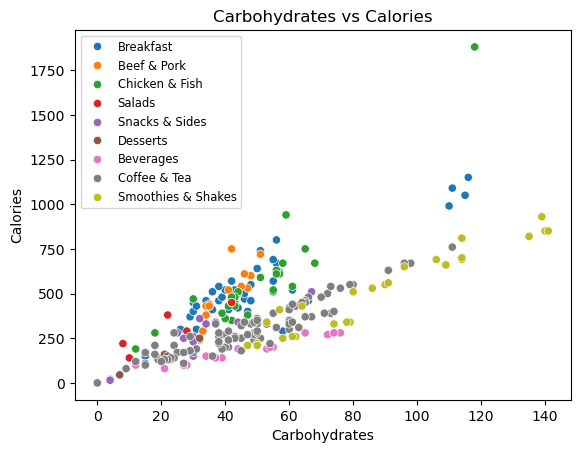

In [4]:
sns.scatterplot(x='Carbohydrates', y= 'Calories', hue='Category', data=mcdonald_menu)

plt.title("Carbohydrates vs Calories")
plt.legend(fontsize='small')
plt.show()


When we plot `Carbohydrates` versus `Calories`, it appears to be difficult to use lines to separate each category.

We can first observe the number of features (number of columns), $m$, and the number of samples $N$ (number of rows) and determine the aspect ratio, $\gamma$ to perform the principal component analysis. 

But why do we care about using the principal component analysis (PCA) befor SVM?
We can treat PCA as a pre-processing step because since it can reveal the features that explains the most variances, and that can mitigate the "curse of dimensionality".

Then comes the question, how do we determine if PCA is an applicable analysis to our dataset?
We can first observe the number of features (number of columns), $m$, and the number of samples $N$ (number of rows) and determine the aspect ratio, $\gamma$ to perform the principal component analysis. In the code below, we define the aspect ratio to be between 1/20 and 20 to start.

In [8]:
rows, columns = mcdonald_menu.shape
gamma = rows/(columns)

def isWithinIdealAspectRatio(gamma):
    return (1/20 <= gamma) and (gamma <= 20)

print(isWithinIdealAspectRatio(gamma))

True
